# LLM Application Evaluation with LangSmith

In this section, we'll set up everything you need to start evaluating your LLM application — which means briefly touching on what evaluation actually is before we build it.

At its core, **evaluation is the practice of systematically measuring how well your AI application performs** — rather than relying on intuition or spot-checking. You run your app against a set of test inputs, compare the outputs to what you'd expect, and get a concrete, repeatable signal.

We'll ground all of this in a practical scenario you'll recognize from the previous course. Let's take a look.

We're picking up where the previous course left off. Here we have a system that **extracts structured information from app reviews** — think ratings, sentiments, and specific opinions about things like UI, payment flow, or customer service.

This is the application we'll be evaluating throughout this lesson.

Here's the implementation from the previous course. It's worth doing a quick recap of the key building blocks before we move into evaluation:

- **`Review` and `Opinion` Pydantic models** define strict input validation rules — things like rating format and review ID pattern.
- `StructuredReview` is the output schema: overall sentiment, notable phrases, and a list of opinions.
- `with_structured_output(StructuredReview)` tells the LLM to return a validated Pydantic object directly.
- `extract_structured_review()` ties it all together — validates the input, builds the prompt, calls the LLM, and returns the structured result.

Take a moment to skim through the code and let me know if anything looks unfamiliar or if you have any questions.

In [7]:
import datetime
import json
from devtools import pprint
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field, ValidationError
from typing import Optional

load_dotenv()


# Define response schema
class Review(BaseModel):
    review_id: str = Field(description="The ID of the review", pattern=r"^R\d{5}$")
    rating: str = Field(
        description="The rating of the review",
        pattern=r"^★{1,5}☆{0,4} \(\d star(?:s)?\)$",
    )
    date: datetime.date = Field(description="The date of the review", json_schema_extra={"format": "YYYY-MM-DD"})
    text: str = Field(
        description="The text of the review", min_length=1, max_length=1000
    )


class Opinion(BaseModel):
    topic: str = Field(
        description="The topic of the opinion, one of (App Functionality, UI & UX, Payment & Checkout, Product Information, Order Operations, Customer Service)"
    )
    sentiment: str = Field(
        description="The sentiment of the opinion (positive, negative, neutral, or mixed)"
    )
    problem: Optional[str] = Field(description="The problem mentioned, if any")
    suggested_solution: Optional[str] = Field(
        description="A suggested solution to the problem, if applicable"
    )


class StructuredReview(BaseModel):
    review_id: str = Field(description="The ID of the review")
    overall_sentiment: str = Field(
        description="The overall sentiment of the review (positive, negative, neutral, or mixed)"
    )
    notable_phrases: list[str] = Field(
        description="Notable phrases or quotes from the review"
    )
    opinions: list[Opinion] = Field(
        description="List of opinions expressed in the review"
    )


llm = init_chat_model(model="gpt-4.1-nano", temperature=0)

# Create a structured LLM that returns validated Pydantic objects
structured_llm = llm.with_structured_output(StructuredReview)


def get_response(prompt_template_str, review, format_instructions):
    prompt_template = PromptTemplate.from_template(prompt_template_str)
    prompt = prompt_template.format(
        review=review, format_instructions=format_instructions
    )
    response = structured_llm.invoke(prompt)
    return response


# Call the LLM to extract the structured review
def extract_structured_review(review_data):
    try:
        Review.model_validate(review_data)
    except ValidationError as e:
        print(f"Input validation error: {e}")
        print("Proceeding with extraction despite validation errors")

    format_instructions = StructuredReview.model_json_schema()

    # Define the prompt template
    prompt_template_str = """
Given the following review:
```
{review}
```

Convert it into a structured JSON object that conforms to the following schema:
{format_instructions}

Output the JSON object only, no other text or delimiters.
"""

    review_str = json.dumps(review_data, indent=4)
    structured_review = get_response(
        prompt_template_str, review_str, format_instructions
    )

    return structured_review


review = {
    "review_id": "R12345",
    "rating": "★★★★☆ (4 stars)",
    "date": "2025-01-01",
    "text": "This is a great product!",
}

response = extract_structured_review(review)
pprint(response)



StructuredReview(
    review_id='R12345',
    overall_sentiment='positive',
    notable_phrases=[
        'This is a great product!',
    ],
    opinions=[
        Opinion(
            topic='Product Information',
            sentiment='positive',
            problem=None,
            suggested_solution=None,
        ),
    ],
)


Now that the app is running, here's the real question: **how do you know it's actually working well?**

Your instinct might be to just look at a few outputs — "that looks right" — or write some unit tests. But both approaches break down quickly for LLM applications:

- **Model variability**: LLM outputs aren't deterministic. Something that works today might produce subtly different results tomorrow, even with the same input.
- **Multiple valid answers**: For a review like "This app is great but checkout is slow," there isn't one single correct structured output. Many valid interpretations exist.

This makes traditional software testing essentially useless here — you can't assert against a fixed expected output when both the model and the problem allow for variation.

And this is where things get interesting for prompt engineering — because it's an inherently iterative process. You're constantly tweaking prompts to fix one issue, and the risk is that each change might silently break something else.

If you can't eyeball results or run standard tests, how do you know your changes are moving you forward and not backward? The answer is simple: you can't improve what you can't measure.

That's the core motivation for evaluation — a systematic way to measure progress. Let's see how it works.

That's exactly it — a dataset of representative inputs with known expected outputs is the foundation. Here's how the full evaluation system is structured around that idea.

The system has four connected components:

- **Evaluation Dataset:** Your collection of input/reference output pairs — the ground truth you just described.
- **AI Application**: The system being evaluated — in our case, the review extractor.
- **Evaluator:** The method that compares the app's output against the reference. This could be exact matching, fuzzy matching, or even another AI model acting as a judge.
- **Metric Calculation**: Aggregates scores across all examples into a final, comparable score.

The flow is straightforward — the dataset feeds inputs into the app, the app produces outputs, evaluators score them against references, and metrics roll everything up into a single signal you can track across prompt iterations.

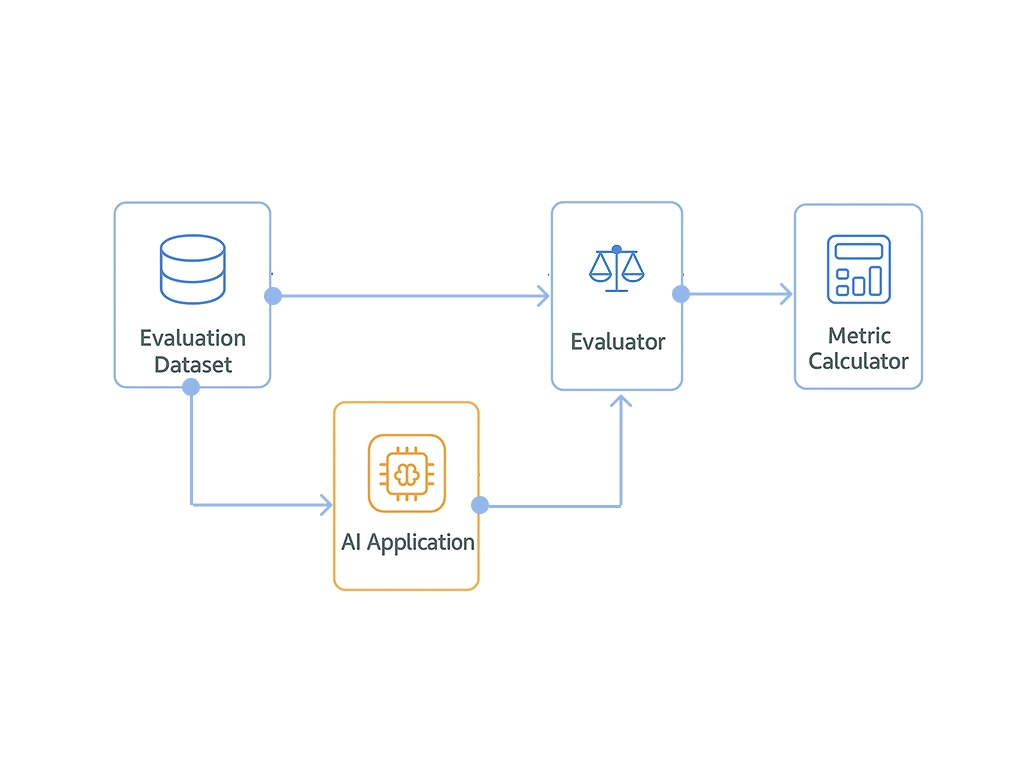

## The model


In [1]:
import datetime
import json
from devtools import pprint
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field, ValidationError
from typing import Optional

load_dotenv()


# Define response schema
class Review(BaseModel):
    review_id: str = Field(description="The ID of the review", pattern=r"^R\d{5}$")
    rating: str = Field(description="The rating of the review", pattern=r"^★{1,5}☆{0,4} \(\d star(?:s)?\)$")
    date: datetime.date = Field(description="The date of the review", json_schema_extra={"format": "YYYY-MM-DD"})
    text: str = Field(description="The text of the review", min_length=1, max_length=1000)


class Opinion(BaseModel):
    topic: str = Field(
        description="The topic of the opinion, one of (App Functionality, UI & UX, Payment & Checkout, Product Information, Order Operations, Customer Service)"
    )
    sentiment: str = Field(
        description="The sentiment of the opinion (positive, negative, neutral, or mixed)"
    )
    problem: Optional[str] = Field(
        default=None, description="The problem mentioned, if any"
    )
    suggested_solution: Optional[str] = Field(
        default=None, description="A suggested solution to the problem, if applicable"
    )


class StructuredReview(BaseModel):
    review_id: str = Field(description="The ID of the review")
    overall_sentiment: str = Field(description="The overall sentiment of the review (positive, negative, neutral, or mixed)")
    notable_phrases: list[str] = Field(description="Notable phrases or quotes from the review")
    opinions: list[Opinion] = Field(description="List of opinions expressed in the review")


# instantiate the foundation model
llm = init_chat_model(model="gpt-4.1-nano", temperature=0)

# Create a structured LLM that returns validated Pydantic objects
structured_llm = llm.with_structured_output(StructuredReview)


def get_response(prompt_template_str, review, format_instructions):
    prompt_template = PromptTemplate.from_template(prompt_template_str)
    prompt = prompt_template.format(
        review=review, format_instructions=format_instructions
    )
    response = structured_llm.invoke(prompt)
    return response


# Call the LLM to extract the structured review
def extract_structured_review(review_data):
    # validate the input structure
    try:
        Review.model_validate(review_data)
    except ValidationError as e:
        print(f"Input validation error: {e}")
        print("Proceeding with extraction despite validation errors")

    format_instructions = StructuredReview.model_json_schema()

    # Define the prompt template
    prompt_template_str = """
Given the following review:
```
{review}
```

Convert it into a structured JSON object that conforms to the following schema:
{format_instructions}

Output the JSON object only, no other text or delimiters.
"""

    review_str = json.dumps(review_data, indent=4)
    structured_review = get_response(
        prompt_template_str, review_str, format_instructions
    )

    return structured_review


In [8]:
import datetime
import json
from devtools import pprint
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field, ValidationError
from typing import Optional

load_dotenv()


# Define response schema
class Review(BaseModel):
    review_id: str = Field(description="The ID of the review", pattern=r"^R\d{5}$")
    rating: str = Field(description="The rating of the review", pattern=r"^★{1,5}☆{0,4} \(\d star(?:s)?\)$")
    date: datetime.date = Field(description="The date of the review", json_schema_extra={"format": "YYYY-MM-DD"})
    text: str = Field(description="The text of the review", min_length=1, max_length=1000)


class Opinion(BaseModel):
    topic: str = Field(
        description="The topic of the opinion, one of (App Functionality, UI & UX, Payment & Checkout, Product Information, Order Operations, Customer Service)"
    )
    sentiment: str = Field(
        description="The sentiment of the opinion (positive, negative, neutral, or mixed)"
    )
    problem: Optional[str] = Field(
        default=None, description="The problem mentioned, if any"
    )
    suggested_solution: Optional[str] = Field(
        default=None, description="A suggested solution to the problem, if applicable"
    )


class StructuredReview(BaseModel):
    review_id: str = Field(description="The ID of the review")
    overall_sentiment: str = Field(description="The overall sentiment of the review (positive, negative, neutral, or mixed)")
    notable_phrases: list[str] = Field(description="Notable phrases or quotes from the review")
    opinions: list[Opinion] = Field(description="List of opinions expressed in the review")


# instantiate the foundation model
llm = init_chat_model(model="gpt-4.1-nano", temperature=0)

# Create a structured LLM that returns validated Pydantic objects
structured_llm = llm.with_structured_output(StructuredReview)


def get_response(prompt_template_str, review, format_instructions):
    prompt_template = PromptTemplate.from_template(prompt_template_str)
    prompt = prompt_template.format(
        review=review, format_instructions=format_instructions
    )
    response = structured_llm.invoke(prompt)
    return response


# Call the LLM to extract the structured review
def extract_structured_review(review_data):
    # validate the input structure
    try:
        Review.model_validate(review_data)
    except ValidationError as e:
        print(f"Input validation error: {e}")
        print("Proceeding with extraction despite validation errors")

    format_instructions = StructuredReview.model_json_schema()

    # Define the prompt template
    prompt_template_str = """
Given the following review:
```
{review}
```

Convert it into a structured JSON object that conforms to the following schema:
{format_instructions}

Output the JSON object only, no other text or delimiters.
"""

    review_str = json.dumps(review_data, indent=4)
    structured_review = get_response(
        prompt_template_str, review_str, format_instructions
    )

    return structured_review


## Loading a dataset

Below we load a dataset from disk (not from langsmith).

In [2]:
import pprint
import json

def load_examples():
    evaluation_dataset_path = "evaluation_dataset.json"

    # Load the evaluation dataset
    with open(evaluation_dataset_path, "r", encoding="utf-8") as file:
        # load the json string and make it (list of) dictionaries
        examples = json.load(file)

    return examples


examples = load_examples()

print(f"The examples are of type: {type(examples)}\n")
print(f"The first example is of type: {type(examples[0])}\n")

pprint.pprint(examples[0])

The examples are of type: <class 'list'>

The first example is of type: <class 'dict'>

{'inputs': {'raw_review': {'date': '2024-04-12',
                           'rating': '★★★★☆ (4 stars)',
                           'review_id': 'R73491',
                           'text': 'Been using this app for about 3 months '
                                   'now. The interface is sleek and intuitive. '
                                   'Love how easy it is to track my orders. '
                                   'Wish there were more filter options '
                                   'though, especially for price range. '
                                   'Sometimes it runs a bit slow on my older '
                                   'phone but nothing major. Overall pretty '
                                   'happy with it!'}},
 'outputs': {'structured_review': {'notable_phrases': ['The interface is sleek '
                                                       'and intuitive',
        

Here's a concrete example of a single evaluation example from our review extraction scenario. It has two parts:

- **Inputs**: The raw review — review ID, rating, date, and text — exactly what gets fed into the application.
- **Reference Outputs**: The expected structured result — overall sentiment, notable phrases, and a list of opinions with topics and sentiments.

In practice, an evaluation example can also carry **metadata** — things like tags or categories that let you filter and group results (e.g., "all negative reviews" or "checkout-related opinions").

An **evaluation** dataset is simply a collection of these examples — ideally covering the range of scenarios your app will encounter in production.

A dataset is essentially a collection of these examples. The key is making sure they collectively represent the variety of inputs your app will face in production — different review lengths, sentiments, topics, and edge cases.

Speaking of which — where do these examples actually come from? Let's look at the different curation approaches.

So where do evaluation examples actually come from? There are four main approaches, and you'll often combine them.

- **Manual Creation**: Domain experts hand-craft examples targeting specific capabilities and edge cases. This is the most reliable approach — a financial domain expert knows exactly what a "correct" SQL query result looks like for a given question.
- **Real-World Examples**: Once your app is live, you can collect actual inputs from production usage. These are invaluable because they reflect what users actually ask.
- **Synthetic Generation**: Examples generated algorithmically or via an LLM — useful for covering edge cases that rarely appear naturally. For your SQL agent, you might synthetically generate tricky multi-join queries.
- **Hybrid Approach:** Combining the above for comprehensive coverage.

In practice, manually created examples from domain experts are the most common starting point — and given your quantitative background in financial markets, you'd be well placed to author high-quality examples for your SQL agent.

Evaluation datasets serve three critical purposes:

- **Reliable measurement**: They give you a concrete, repeatable signal to track whether your changes are improving or degrading performance.
- **Forcing clarity**: Building examples forces you and domain experts to think deeply about requirements and edge cases. If you can't come up with examples, you probably don't understand the problem well enough yet.
- **Aligning expectations**: Application builders are rarely domain experts. Having domain experts define test examples is how they communicate what "good" actually looks like.

This is why the rule of thumb is: never start building an AI application until you have a high-quality evaluation dataset. For your SQL agent, that means having financial domain experts define what correct query results look like before you write a single line of prompt code.

There's one nuance — very simple, low-stakes applications might get away with minimal evaluation. But for anything production-quality, especially in a risk-sensitive domain like financial markets, proper evaluation is non-negotiable.

## Pushing a dataset to langsmith

Now let's push that dataset to LangSmith. The new code is highlighted at the bottom.

Here's what's happening:

- `Client()` initializes the LangSmith client, authenticating using your API key from the `.env` file
- `client.has_dataset()` checks whether a dataset with the given name already exists — so we don't create duplicates
- If it doesn't exist, `client.create_dataset()` creates it with a name and description
- Then `client.create_examples()` uploads all 17 examples, linking them to the new dataset via dataset.id

Note the idempotency pattern here — running this multiple times is safe because it only creates the dataset once.

Go ahead and run the code.

In [4]:
# Import LangSmith-related libraries
from langsmith import Client
from langsmith.evaluation import evaluate
from openevals.llm import create_llm_as_judge

from dotenv import load_dotenv

load_dotenv()

client = Client()  # Initialize LangSmith client

dataset_name = "app_reviews_01"


if client.has_dataset(dataset_name=dataset_name):
    print(f"Using existing dataset: {dataset_name}")
else:
    # Create a new dataset if not found
    print(f"Creating new dataset: {dataset_name}")
    dataset = client.create_dataset(
        dataset_name=dataset_name,
        description="Dataset for evaluating app review structured extraction",
    )

    examples = load_examples()
    client.create_examples(dataset_id=dataset.id, examples=examples)
    print(f"Dataset Created with {len(examples)} examples")

Creating new dataset: app_reviews_01
Dataset Created with 18 examples


In [5]:
examples[1]

{'inputs': {'raw_review': {'date': '2024-04-15',
   'text': "I've been using this app for almost a year. The experience has gotten worse since the new version. Things that used to take one tap now require navigating through multiple menus. On the bright side, the new design looks more modern, and I haven't experienced any crashes like some other reviewers mentioned.",
   'rating': '★★★☆☆ (3 stars)',
   'review_id': 'R73496'}},
 'outputs': {'structured_review': {'review_id': 'R73496',
   'overall_sentiment': 'mixed',
   'notable_phrases': ['experience has gotten worse since the new version',
    'the new design looks more modern',
    "I haven't experienced any crashes"],
   'opinions': [{'topic': 'App Functionality',
     'sentiment': 'negative',
     'problem': 'Tasks that used to take one tap now require navigating through multiple menus',
     'suggested_solution': ''},
    {'topic': 'UI & UX',
     'sentiment': 'positive',
     'problem': '',
     'suggested_solution': 'Maintain th

#### intermezza: openevals

**Note** move this intermezzo if it is not used

openevals is an open-source evaluation library built by the LangChain team that provides ready-made evaluator components — particularly LLM-as-Judge evaluators.

Rather than building judge evaluators from scratch, openevals gives you create_llm_as_judge and other utilities that handle the boilerplate of setting up an LLM to score outputs. We imported it here alongside the LangSmith client, and we'll use it heavily when we get to the LLM-as-Judge evaluators in a few steps.

For now it's just being imported — the action is all in the LangSmith client code below it. Go ahead and run the code when you're ready!
#### end

## Evaluation

**remark** - this is rather complicated so read it two times and examine the code below. This is a **key** step.

Now let's build our first evaluator. The goal here is to check whether the app correctly identifies the **overall sentiment** of a review — positive, negative, neutral, or mixed.

This is a perfect fit for **algorithmic evaluation**: the answer is objective, we have reference outputs, and the comparison can be expressed as a simple equality check in code.

Look at the highlighted new code:

- `overall_sentiment_correctness_evaluator` takes the standard three-parameter signature — `inputs`, `outputs`, and `reference_outputs` — and returns a boolean by comparing `outputs["overall_sentiment"]` against the reference.
  - `reference_outputs` refers to the expected output stored in the **dataset**. So `reference_outputs["structured_review"]["overall_sentiment"]` comes from the **Reference Output** column in LangSmith.
  - the `outputs` is what is returned by the reference function (model), in this case `app_to_evaluate`. Because we use .model_dump() it returns a dictionary and that is why it can be accessed using `outputs['overall_sentiment']`

- `app_to_evaluate` is the prediction function — it wraps `extract_structured_review` and formats the result as a dictionary for LangSmith.

- The `evaluate` call ties it all together: it runs `app_to_evaluate` on every example in the dataset, applies each evaluator, and logs everything under the `experiment_prefix`.

Go ahead and **run the code** — this will take a moment as it processes all 18 examples.

I think langsmith will access feed the dataset via the argument `inputs` (app_to_evaluate function below) so that is why we see `example['raw_review']` below. A raw example looks like:

In [4]:
example = examples[0]['inputs']
example

{'raw_review': {'date': '2024-04-12',
  'text': 'Been using this app for about 3 months now. The interface is sleek and intuitive. Love how easy it is to track my orders. Wish there were more filter options though, especially for price range. Sometimes it runs a bit slow on my older phone but nothing major. Overall pretty happy with it!',
  'rating': '★★★★☆ (4 stars)',
  'review_id': 'R73491'}}

This example if then fed to our model `extract_structured_review` to obtain a result and model_dump to turn in into a dictionary.

In [5]:
extract_structured_review(examples[0]['inputs']['raw_review']).model_dump()

{'review_id': 'R73491',
 'overall_sentiment': 'positive',
 'notable_phrases': ['The interface is sleek and intuitive.',
  'Love how easy it is to track my orders.',
  'Overall pretty happy with it!'],
 'opinions': [{'topic': 'UI & UX',
   'sentiment': 'positive',
   'problem': None,
   'suggested_solution': None},
  {'topic': 'Order Operations',
   'sentiment': 'neutral',
   'problem': 'Wish there were more filter options though, especially for price range.',
   'suggested_solution': 'Add more filter options for price range.'},
  {'topic': 'App Performance',
   'sentiment': 'neutral',
   'problem': 'Sometimes it runs a bit slow on my older phone but nothing major.',
   'suggested_solution': None}]}

In [6]:
# Define the evaluator
def overall_sentiment_correctness_evaluator(
    inputs: dict, outputs: dict, reference_outputs: dict
):
    return (
        outputs["overall_sentiment"]
        == reference_outputs["structured_review"]["overall_sentiment"]
    )


# Define the prediction function
def app_to_evaluate(example):
    return extract_structured_review(example["raw_review"]).model_dump()


# Define evaluators
evaluators = [
    # 1. Exact match for overall sentiment
    overall_sentiment_correctness_evaluator,
]

experiment_name = "app_review_extraction_evaluation"

# Run the evaluation
results = evaluate(
    app_to_evaluate,  # The prediction function
    data=dataset_name,
    evaluators=evaluators,
    experiment_prefix=experiment_name,
    max_concurrency=5,  # Parallelize for faster evaluation
)



View the evaluation results for experiment: 'app_review_extraction_evaluation-c7c2d1fc' at:
https://smith.langchain.com/o/1b1c01bf-b2ed-48d5-9e2a-040bacfc157a/datasets/a415a763-511b-4e77-934e-fb0ade02f33c/compare?selectedSessions=355afcbe-12f3-43eb-9c53-53aa01e6bf16




0it [00:00, ?it/s]

## Create a topic similarity evaluator

In [9]:
from pprint import pprint
inputs = examples[0]['inputs']
pprint(inputs)
reference_outputs = examples[0]['outputs']
print("Dataset reference output")
pprint(reference_outputs)
print('*'*90)
print("Application output (LLM)")
outputs = extract_structured_review(examples[0]['inputs']['raw_review']).model_dump()
pprint(outputs)

{'raw_review': {'date': '2024-04-12',
                'rating': '★★★★☆ (4 stars)',
                'review_id': 'R73491',
                'text': 'Been using this app for about 3 months now. The '
                        'interface is sleek and intuitive. Love how easy it is '
                        'to track my orders. Wish there were more filter '
                        'options though, especially for price range. Sometimes '
                        'it runs a bit slow on my older phone but nothing '
                        'major. Overall pretty happy with it!'}}
Dataset reference output
{'structured_review': {'notable_phrases': ['The interface is sleek and '
                                           'intuitive',
                                           'Love how easy it is to track my '
                                           'orders',
                                           'Overall pretty happy with it!'],
                       'opinions': [{'problem': '',
           

In [10]:
def topic_similarity_evaluator(
      inputs: dict, outputs: dict, reference_outputs: dict
):
    # ground truth
    target_opinions = reference_outputs['structured_review']['opinions']
    # print(target_opinions)

    # model outcomes - predictions
    opinions = outputs['opinions']
    # print(opinions)

    set1 = {rec['topic'] for rec in target_opinions}
    set2 = {rec['topic'] for rec in opinions}
    # print(set1)
    # print(set2)

    intersection = set1.intersection(set2)
    # print(intersection)

    union = set1.union(set2)
    # print(union)
    return len(intersection)/len(union)


In [11]:
opinions = topic_similarity_evaluator(inputs, outputs, reference_outputs)

In [12]:
opinions

0.4

In [13]:
dataset_name

'app_reviews_01'

In [14]:
# Define evaluators
evaluators = [
    # 1. Exact match for overall sentiment
    overall_sentiment_correctness_evaluator,
    topic_similarity_evaluator
]

experiment_name = "app_review_evaluator"
dataset_name= "app_reviews_01"

# Run the evaluation
results = evaluate(
    app_to_evaluate,  # The prediction function
    data=dataset_name,
    evaluators=evaluators,
    experiment_prefix=experiment_name,
    max_concurrency=5,  # Parallelize for faster evaluation
)


View the evaluation results for experiment: 'app_review_evaluator-5dea48ce' at:
https://smith.langchain.com/o/1b1c01bf-b2ed-48d5-9e2a-040bacfc157a/datasets/a415a763-511b-4e77-934e-fb0ade02f33c/compare?selectedSessions=98e69eec-f0bc-41b0-9fc1-189e5f4704d9




0it [00:00, ?it/s]

## Code so far

In [15]:
import datetime
import json
from devtools import pprint
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field, ValidationError
from typing import Optional

load_dotenv()


# Define response schema
class Review(BaseModel):
    review_id: str = Field(description="The ID of the review", pattern=r"^R\d{5}$")
    rating: str = Field(
        description="The rating of the review",
        pattern=r"^★{1,5}☆{0,4} \(\d star(?:s)?\)$",
    )
    date: datetime.date = Field(
        description="The date of the review", format="YYYY-MM-DD"
    )
    text: str = Field(
        description="The text of the review", min_length=1, max_length=1000
    )


class Opinion(BaseModel):
    topic: str = Field(
        description="The topic of the opinion, one of (App Functionality, UI & UX, Payment & Checkout, Product Information, Order Operations, Customer Service)"
    )
    sentiment: str = Field(
        description="The sentiment of the opinion (positive, negative, neutral, or mixed)"
    )
    problem: Optional[str] = Field(
        default=None, description="The problem mentioned, if any"
    )
    suggested_solution: Optional[str] = Field(
        default=None, description="A suggested solution to the problem, if applicable"
    )


class StructuredReview(BaseModel):
    review_id: str = Field(description="The ID of the review")
    overall_sentiment: str = Field(
        description="The overall sentiment of the review (positive, negative, neutral, or mixed)"
    )
    notable_phrases: list[str] = Field(
        description="Notable phrases or quotes from the review"
    )
    opinions: list[Opinion] = Field(
        description="List of opinions expressed in the review"
    )


llm = init_chat_model(model="gpt-4.1-nano", temperature=0)

# Create a structured LLM that returns validated Pydantic objects
structured_llm = llm.with_structured_output(StructuredReview)


def get_response(prompt_template_str, review, format_instructions):
    prompt_template = PromptTemplate.from_template(prompt_template_str)
    prompt = prompt_template.format(
        review=review, format_instructions=format_instructions
    )
    response = structured_llm.invoke(prompt)
    return response


# Call the LLM to extract the structured review
def extract_structured_review(review_data):
    try:
        Review.model_validate(review_data)
    except ValidationError as e:
        print(f"Input validation error: {e}")
        print("Proceeding with extraction despite validation errors")

    format_instructions = StructuredReview.model_json_schema()

    # Define the prompt template
    prompt_template_str = """
Given the following review:
```
{review}
```

Convert it into a structured JSON object that conforms to the following schema:
{format_instructions}

Output the JSON object only, no other text or delimiters.
"""

    review_str = json.dumps(review_data, indent=4)
    structured_review = get_response(
        prompt_template_str, review_str, format_instructions
    )

    return structured_review


def load_examples():
    evaluation_dataset_path = "data/llm-application-evaluation/evaluation-implementation/evaluation_dataset.json"

    # Load the evaluation dataset
    with open(evaluation_dataset_path, "r", encoding="utf-8") as file:
        examples = json.load(file)

    return examples


# Import LangSmith-related libraries
from langsmith import Client
from langsmith.evaluation import evaluate
from openevals.llm import create_llm_as_judge

client = Client()  # Initialize LangSmith client

dataset_name = "app_reviews_01"


if client.has_dataset(dataset_name=dataset_name):
    print(f"Using existing dataset: {dataset_name}")
else:
    # Create a new dataset if not found
    print(f"Creating new dataset: {dataset_name}")
    dataset = client.create_dataset(
        dataset_name=dataset_name,
        description="Dataset for evaluating app review structured extraction",
    )

    examples = load_examples()
    client.create_examples(dataset_id=dataset.id, examples=examples)
    print(f"Dataset Created with {len(examples)} examples")


# Define the evaluator
def overall_sentiment_correctness_evaluator(
    inputs: dict, outputs: dict, reference_outputs: dict
):
    return (
        outputs["overall_sentiment"]
        == reference_outputs["structured_review"]["overall_sentiment"]
    )


def topic_similarity_evaluator(
      inputs: dict, outputs: dict, reference_outputs: dict
):
    # ground truth
    target_opinions = reference_outputs['structured_review']['opinions']
    # print(target_opinions)

    # model outcomes - predictions
    opinions = outputs['opinions']
    # print(opinions)

    set1 = {rec['topic'] for rec in target_opinions}
    set2 = {rec['topic'] for rec in opinions}
    # print(set1)
    # print(set2)

    intersection = set1.intersection(set2)
    # print(intersection)

    union = set1.union(set2)
    # print(union)
    return len(intersection)/len(union)

# Define the prediction function
def app_to_evaluate(example):
    return extract_structured_review(example["raw_review"]).model_dump()


# Define evaluators
evaluators = [
    # 1. Exact match for overall sentiment
    overall_sentiment_correctness_evaluator,
    topic_similarity_evaluator
]

experiment_name = "app_review_evaluator"
dataset_name= "app_reviews_01"

# Run the evaluation
results = evaluate(
    app_to_evaluate,  # The prediction function
    data=dataset_name,
    evaluators=evaluators,
    experiment_prefix=experiment_name,
    max_concurrency=5,  # Parallelize for faster evaluation
)

/tmp/ipykernel_107581/3437124627.py:21: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'format'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  date: datetime.date = Field(


Using existing dataset: app_reviews_01
View the evaluation results for experiment: 'app_review_evaluator-f1e70f3a' at:
https://smith.langchain.com/o/1b1c01bf-b2ed-48d5-9e2a-040bacfc157a/datasets/a415a763-511b-4e77-934e-fb0ade02f33c/compare?selectedSessions=1ee17d0c-4be7-400a-aa7c-2664d9c2e6ee




0it [00:00, ?it/s]

## LLM-as-judge

### using `create_llm_as_judge`

In [16]:
def problem_correctness_evaluator(inputs: dict, outputs: dict, reference_outputs: dict):
    problem_correctness_prompt = """
For each opinion in the reference output, compute and return the following score:

- problem_correctness: Count the number of opinions in the output
  that have the same problem. Return the ratio of opinions with matched
  problems to the total number of opinions in the reference output (
  matched_opinion_problem_count / reference_opinion_count).

Here is the input:
{inputs}

Here is the output:
{outputs}

Here is the reference output:
{reference_outputs}
"""

    evaluator = create_llm_as_judge(
        model="gpt-4o",
        prompt=problem_correctness_prompt,
        continuous=True,
        feedback_key="problem_correctness",
    )
    eval_result = evaluator(
        inputs=inputs, outputs=outputs, reference_outputs=reference_outputs
    )

    return eval_result


evaluators = [
    problem_correctness_evaluator,
]

experiment_name = "app_review_extraction_evaluation"

results = evaluate(
    app_to_evaluate,
    data=dataset_name,
    evaluators=evaluators,
    experiment_prefix=experiment_name,
    max_concurrency=5,
)

View the evaluation results for experiment: 'app_review_extraction_evaluation-41a2d2c9' at:
https://smith.langchain.com/o/1b1c01bf-b2ed-48d5-9e2a-040bacfc157a/datasets/a415a763-511b-4e77-934e-fb0ade02f33c/compare?selectedSessions=5efb32c8-5305-4fba-a5a8-1065e889f29b




0it [00:00, ?it/s]

### without `create_llm_as_judge`

In [22]:
from pydantic import BaseModel, Field

class ProblemCorrectnessScore(BaseModel):
    score: float = Field(description="Ratio of matched problems, between 0 and 1")

judge_llm = init_chat_model(model="gpt-4o", temperature=0)
structured_judge = judge_llm.with_structured_output(ProblemCorrectnessScore)

def problem_correctness_evaluator(inputs, outputs, reference_outputs):
    prompt = f"""
For each opinion in the reference output, compute and return the following score:

- problem_correctness: Count the number of opinions in the output
  that have the same problem. Return the ratio of opinions with matched
  problems to the total number of opinions in the reference output (
  matched_opinion_problem_count / reference_opinion_count).

Here is the input:
{inputs}

Here is the output:
{outputs}

Here is the reference output:
{reference_outputs}
"""
    result = structured_judge.invoke(prompt)
    return {"key": "problem_correctness", "score": result.score}


evaluators = [
    problem_correctness_evaluator,
]

experiment_name = "app_review_extraction_evaluation"

results = evaluate(
    app_to_evaluate,
    data=dataset_name,
    evaluators=evaluators,
    experiment_prefix=experiment_name,
    max_concurrency=5,
)

View the evaluation results for experiment: 'app_review_extraction_evaluation-a34a0562' at:
https://smith.langchain.com/o/1b1c01bf-b2ed-48d5-9e2a-040bacfc157a/datasets/a415a763-511b-4e77-934e-fb0ade02f33c/compare?selectedSessions=2286227e-eecf-4ece-9421-52d6508a6e06




0it [00:00, ?it/s]

In [23]:
results

,inputs.raw_review,outputs.review_id,outputs.overall_sentiment,outputs.notable_phrases,outputs.opinions,error,reference.structured_review,feedback.problem_correctness,execution_time,example_id,id
0,"{'date': '2024-04-10', 'text': 'The app does w...",R73494,mixed,[The delivery tracking is excellent and always...,"[{'topic': 'App Functionality', 'sentiment': '...",None,"{'opinions': [{'topic': 'Order Operations', 'p...",0.666667,1.374417,7716e4dd-6bf6-4489-879f-78f824c0722f,019e45a7-0a94-7440-8c59-b463a2e4b6ca
1,"{'date': '2024-04-05', 'text': 'App OK 4 basic...",R73492,negative,"[MAJOR ISSUE: payment system glitchy af!!!, tr...","[{'topic': 'Payment & Checkout', 'sentiment': ...",None,"{'opinions': [{'topic': 'Payment & Checkout', ...",0.500000,1.196691,8804eb6a-82b0-48bb-92b5-a5d3f0aca924,019e45a7-0a98-7693-ae1c-5d406f98cf88
2,"{'date': '2024-04-08', 'text': 'This app has p...",R73493,negative,[This app has potential but there are too many...,"[{'topic': 'App Functionality', 'sentiment': '...",None,"{'opinions': [{'topic': 'App Functionality', '...",0.800000,1.204971,3c7f2786-a77b-431c-a31a-c2da1b30d3e1,019e45a7-0a8f-7212-8352-7a9499c4a4bb
3,"{'date': '2024-04-30', 'text': 'Been using the...",R73482,mixed,[Love the loyalty program and how easy checkou...,"[{'topic': 'App Functionality', 'sentiment': '...",None,"{'opinions': [{'topic': 'Payment & Checkout', ...",0.666667,1.217249,8f14b971-d562-4ec8-9112-eeed3f1f00d2,019e45a7-0a99-75d3-a8f2-d7401bc1392a
4,"{'date': '2024-04-12', 'text': 'Been using thi...",R73491,positive,"[The interface is sleek and intuitive., Love h...","[{'topic': 'UI & UX', 'sentiment': 'positive',...",None,"{'opinions': [{'topic': 'UI & UX', 'problem': ...",0.500000,1.391032,4bac4fc8-e576-4a80-80dc-2f681c1e2026,019e45a7-0a90-7390-b9a7-687ac885ef24
5,"{'date': '2024-04-29', 'text': 'bad.', 'rating...",R73481,negative,[bad.],"[{'topic': 'App Functionality', 'sentiment': '...",None,"{'opinions': [], 'review_id': 'R73481', 'notab...",0.000000,0.683215,c182325b-97e8-404e-98b7-b6c27d85a143,019e45a7-0f48-7972-9c36-a3ca7f514d19
6,"{'date': '2024-05-02', 'text': 'I can't seem t...",R73484,negative,[I can't seem to get anything done with this a...,"[{'topic': 'UI & UX', 'sentiment': 'negative',...",None,"{'opinions': [{'topic': 'UI & UX', 'problem': ...",0.500000,1.033656,d3096e40-b63e-4249-a4ec-a31bfd23af94,019e45a7-1000-79a3-8370-e289674e45d7
7,"{'date': '2024-04-22', 'text': 'The API integr...",R73487,negative,[The API integration with my inventory system ...,"[{'topic': 'App Functionality', 'sentiment': '...",None,"{'opinions': [{'topic': 'App Functionality', '...",0.800000,1.035639,d06f0ace-bd7c-432a-b10b-d9400434d7b3,019e45a7-0ff2-7830-9ddb-0068c43ddefb
8,"{'date': '2024-05-03', 'text': 'Great app over...",R73485,mixed,"[Great app overall!, Love how fast it works bu...","[{'topic': 'UI & UX', 'sentiment': 'negative',...",None,"{'opinions': [{'topic': 'App Functionality', '...",0.666667,1.467806,ce26a0ce-a448-4012-8839-28a409960933,019e45a7-0f5b-7292-a6a1-bcc47d9a71b0
9,"{'date': '2024-04-15', 'text': 'I've been usin...",R73496,mixed,[The experience has gotten worse since the new...,"[{'topic': 'UI & UX', 'sentiment': 'mixed', 'p...",None,"{'opinions': [{'topic': 'App Functionality', '...",0.500000,1.504136,d6c1f101-c0e8-441a-86a5-b2664b37fe8a,019e45a7-11f3-7d90-9268-7dfc2dd6f86f


Before we go deeper, let's step back and look at the big picture — when do you actually use each evaluator type?

The decision tree here captures the logic:

- Reference outputs available + output comparable with code → Algorithmic (exact match, Jaccard, etc.)
- Reference outputs available + comparison requires judgment → LLM-as-Judge with references
- No reference outputs + clear evaluation criteria → LLM-as-Judge with criteria
- No reference outputs + no clear criteria → Human evaluation

Thinking about your own work — you mentioned extracting structured data from model risk findings (source, deadline, severity, etc.). Which evaluator type would you reach for first, and why?

**note** at the top of the decision three below there should be a **yes/no**

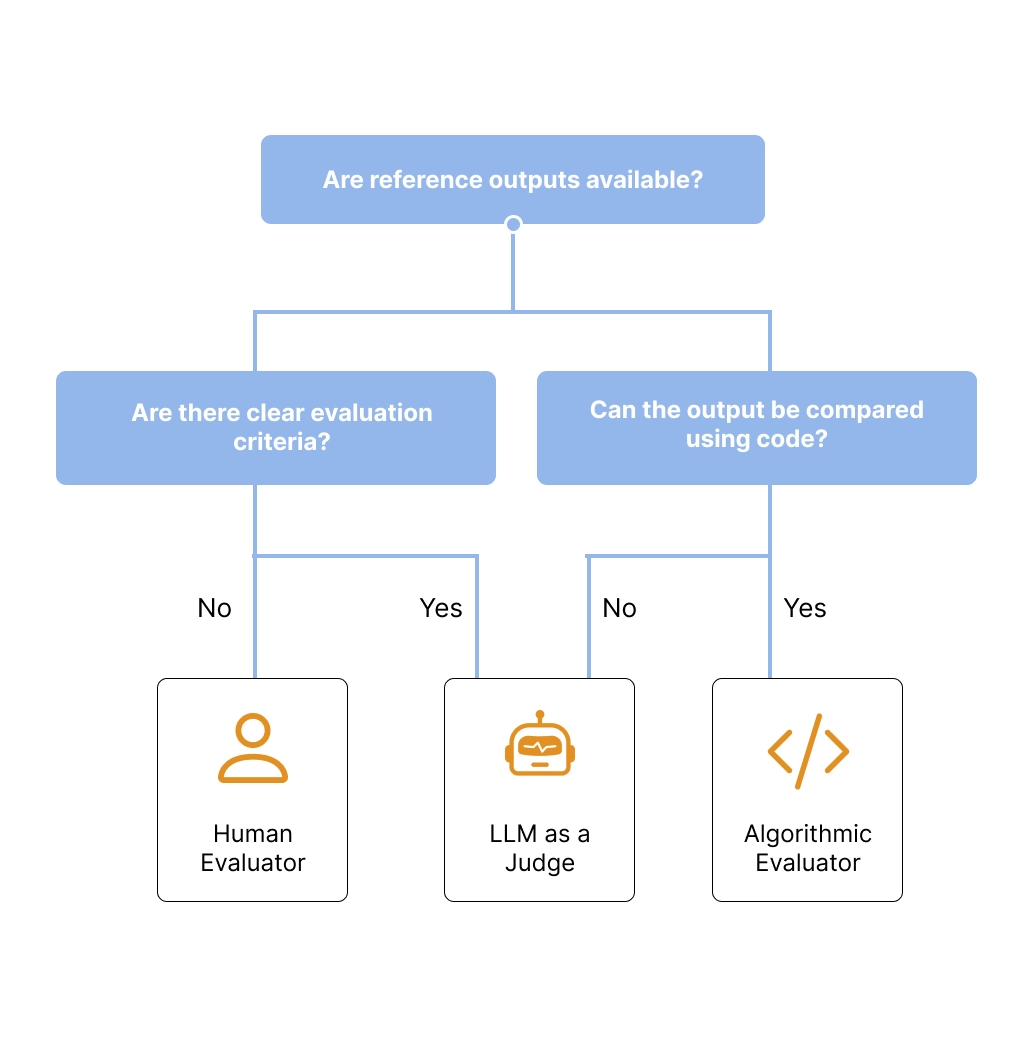!

So far each evaluator returns a **single metric**. But what if you want to evaluate both `problem_correctness` and `solution_correctness` in one LLM call? Making two separate judge calls for related metrics is wasteful — the judge needs the same context both times.

The new code introduces a multi-metric evaluator using a Pydantic schema:

- `OpinionCorrectness` defines the structured output — four fields: `problem_correctness`, `solution_correctness`, and an explanation for each. Passing this as output_schema to `create_llm_as_judge` forces the judge to return a structured object instead of a raw float.
- `average_opinion_problem_and_solution_correctness_evaluator` calls the judge once and gets both scores back as a typed Pydantic object (`eval_result.problem_correctness`, `eval_result.solution_correctness`)
- It then returns a list of dicts, each with `key`, `score`, and `comment` — this is the format LangSmith expects for multiple metrics from a single evaluator

Note that `solution_correctness` is conditional: it only counts solutions that match among opinions that already matched on problem — so it's a stricter metric.

We'll run this together with `overall_sentiment_correctness_evaluator` in the next step. Any questions on the structure before we move on?

This is the moment everything has been building toward — the full experiment combining all three evaluators:

- overall_sentiment_correctness_evaluator (algorithmic)
- average_opinion_problem_and_solution_correctness_evaluator (LLM-as-Judge, multi-metric)

The evaluate() call at the bottom ties it all together — same pattern as before, just with both evaluators in the list.

Go ahead and run it — it'll take about 30 seconds since the LLM judge is evaluating all 18 examples.

In [24]:
class OpinionCorrectness(BaseModel):
    problem_correctness: float = Field(
        description="The ratio of opinions in the output that have the same problem as the reference output to the total number of opinions in the reference output"
    )
    solution_correctness: float = Field(
        description="The ratio of opinions in the output that have the same solution as the reference output to the total number of opinions in the reference output"
    )
    problem_score_explanation: str = Field(
        description="A short explanation of the problem score"
    )
    solution_score_explanation: str = Field(
        description="A short explanation of the solution score"
    )


def average_opinion_problem_and_solution_correctness_evaluator(
    inputs: dict, outputs: dict, reference_outputs: dict
):
    opinion_correctness_prompt = """
For each opinion in the reference output, compute and return the following
two scores:

- problem_correctness: Count the number of opinions in the output
  that have the same problem. Return the ratio of opinions with matched
  problems to the total number of opinions in the reference output (
  matched_opinion_problem_count / reference_opinion_count).
- solution_correctness: Out of the opinions in the output that
  have the same problem as the reference output, count the number of opinions
  that have the same solution. Return the ratio of opinions with matched
  problem and solution to the total number of opinions in the reference
  output (matched_opinion_problem_and_solution_count /
  reference_opinion_count).

Here is the input:
{inputs}

Here is the output:
{outputs}

Here is the reference output:
{reference_outputs}
"""

    evaluator = create_llm_as_judge(
        model="openai:gpt-4o",
        prompt=opinion_correctness_prompt,
        continuous=True,
        feedback_key="opinion_correctness",
        output_schema=OpinionCorrectness,
    )
    eval_result = evaluator(
        inputs=inputs, outputs=outputs, reference_outputs=reference_outputs
    )

    # Convert the schema-based result to the format expected by LangSmith for multiple metrics
    return [
        {
            "key": "problem_correctness",
            "score": eval_result.problem_correctness,
            "comment": eval_result.problem_score_explanation,
        },
        {
            "key": "solution_correctness",
            "score": eval_result.solution_correctness,
            "comment": eval_result.solution_score_explanation,
        },
    ]


evaluators = [
    overall_sentiment_correctness_evaluator,
    average_opinion_problem_and_solution_correctness_evaluator,
]

experiment_name = "app_review_extraction_evaluation"

results = evaluate(
    app_to_evaluate,
    data=dataset_name,
    evaluators=evaluators,
    experiment_prefix=experiment_name,
    max_concurrency=5,
)


View the evaluation results for experiment: 'app_review_extraction_evaluation-9aeb0e5f' at:
https://smith.langchain.com/o/1b1c01bf-b2ed-48d5-9e2a-040bacfc157a/datasets/a415a763-511b-4e77-934e-fb0ade02f33c/compare?selectedSessions=d9ba4a0d-2e2f-43c5-b7e9-7a20917867db




0it [00:00, ?it/s]

We've only scratched the surface of LangSmith today. Beyond what we used, the platform also lets you:

- **Filter and sort runs** by metadata, inputs, or performance metrics to drill into specific failure patterns
- **Use the Playground** to experiment with prompt variations directly from a run
- **Create annotation queues** to route specific examples to human reviewers
- **Convert runs into dataset examples** — so good production outputs automatically enrich your evaluation dataset

We'll keep coming back to LangSmith throughout the course, but I'd encourage you to explore it on your own too — there's a lot there.

## When evaluation

Now let's take a step back and think about when evaluation fits into your development process.

The flow here is simple but powerful: Define Success **Criteria → Develop → Measure → Release**- (or loop back if criteria aren't met yet).

The key insight is the starting point — success criteria come first, before writing a single line of application code. Specifically:

- Task Performance: what accuracy level is acceptable for your use case?
- Cost: what's your budget per 1,000 calls?
- Latency: what response time will users tolerate?

This changes the entire development dynamic. Instead of building and then wondering if it's "good enough", you define what good means upfront — and every prompt change, model swap, or architecture decision gets measured against those targets.

For your model risk extraction work, this means deciding before you build: "I need 90% problem identification accuracy and under 2s latency" — then using your evaluation pipeline to know exactly when you've hit that bar.

For more on setting effective success criteria, Anthropic has a great guide worth bookmarking.

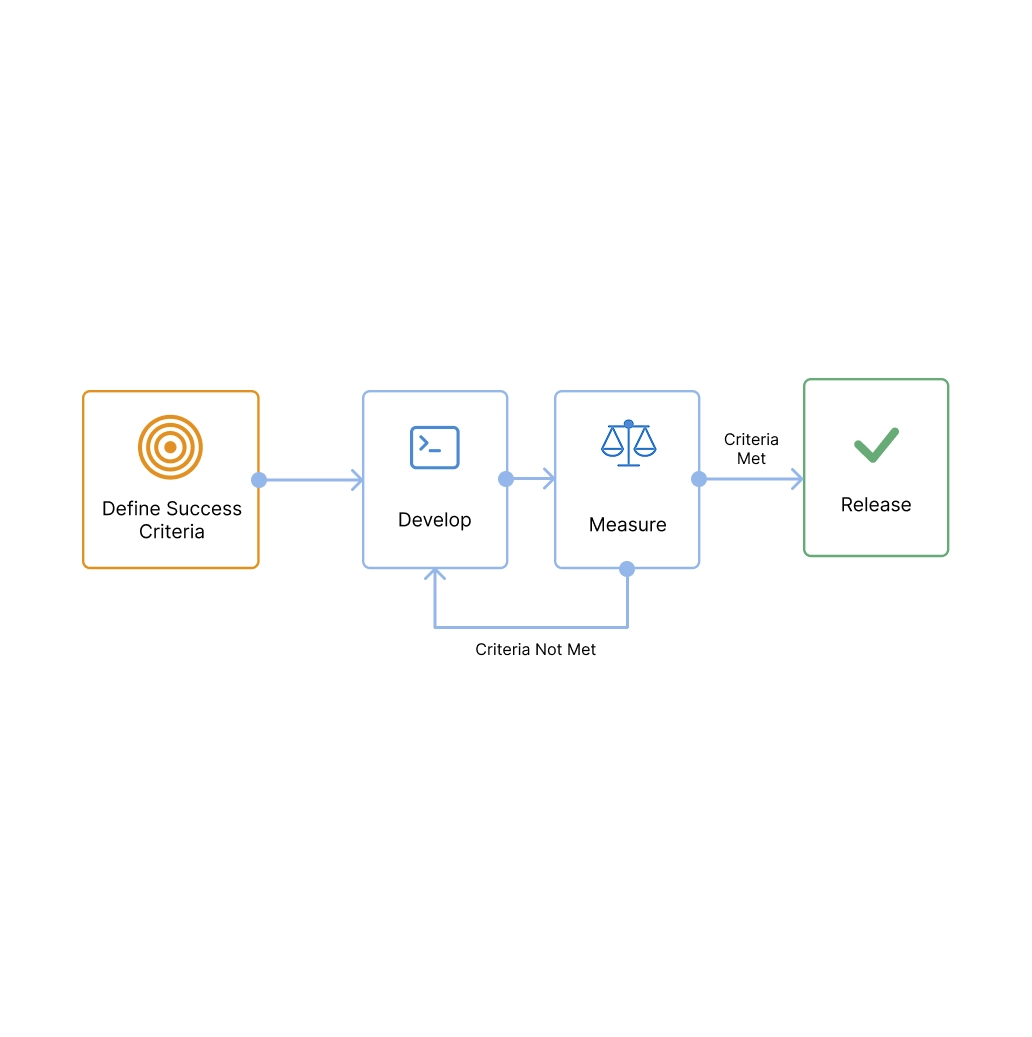!

## Summary

#### Dataset Creation in LangSmith

- Establishes a central repository for consistent test examples with version history and integration with experiment tools

```python
from langsmith import Client

# Create a LangSmith client
ls_client = Client()


def create_dataset(dataset_name, description = ""):
    if ls_client.has_dataset(dataset_name = dataset_name):
        print(f"Using existing dataset: {dataset_name}")
    else:
        # Create new dataset if not found
        dataset = ls_client.create_dataset(
            dataset_name = dataset_name,
            description = description
        )
        print(f"Created new dataset: {dataset_name}")



def add_examples_to_dataset(dataset_id, examples_data):
    ls_client.create_examples(dataset_id = dataset_id,
                           examples = examples_data)
    print(f"Added {len(examples_data)} examples to dataset")
```
- Functions handle both creating new datasets and retrieving existing ones by name
- Examples are structured with distinct "inputs" and "reference_outputs" keys for clarity and consistency

#### Algorithmic Evaluator

Custom function that programmatically compares model outputs against reference outputs using objective criteria

```python
def algorithmic_evaluator(inputs, outputs, reference_outputs):
    """
    Compare outputs against reference outputs using algorithmic criteria.

    Args:
        inputs: The input data provided to the model
        outputs: The output generated by the model
        reference_outputs: The expected or reference output

    Returns:
        Boolean or numeric result indicating correctness or similarity
    """
    # Example implementation: Check if sentiment matches
    return outputs["sentiment"] == reference_outputs["expected_sentiment"]
```

- Takes three dictionary parameters: inputs (original data), outputs ( model's results), and reference_outputs (expected results)
- Returns boolean or numeric results that can be aggregated across examples to measure performance
- Can implement any comparison logic from simple matching to complex similarity metrics based on domain requirements

#### LLM as a Judge Evaluator

- Uses another language model to evaluate outputs based on specified criteria, particularly useful for subjective assessments
```python
from openevals.llm import create_llm_as_judge


def create_llm_judge():
    """Create an LLM-based evaluator for assessing output quality"""
    criteria_prompt = """
    Compute a score between 0 and 1 that measures how correct the output is compared to the reference.

    Here is the input: {inputs}
    Here is the output: {outputs}
    Here is the reference output: {reference_outputs}
    """

    return create_llm_as_judge(
        model = "openai:gpt-4o",
        prompt = criteria_prompt,
        continuous = True,  # For numeric score between 0 and 1
        feedback_key = "correctness"
    )
```

- Configured with a specific model, evaluation prompt, output format ( continuous for numeric scores), and a key for storing feedback
- Prompt template structures how the LLM should evaluate by providing context, outputs, reference, and assessment criteria
- Particularly valuable when variation is allowed but outputs still need to meet specific quality standards

#### Multi-Metric Evaluator

Returns multiple performance metrics from a single evaluation call to provide multidimensional quality assessment

```python
from pydantic import BaseModel, Field
from openevals.llm import create_llm_as_judge


class EvaluationMetrics(BaseModel):
    accuracy_score: float = Field(
        description = "Score from 0-1 measuring factual accuracy")
    coherence_score: float = Field(
        description = "Score from 0-1 measuring logical flow")
    explanation1: str = Field(
        description = "Explanation for the accuracy score")
    explanation2: str = Field(
        description = "Explanation for the coherence score")


def multi_metric_evaluator(inputs, outputs, reference_outputs):
    """
    Evaluate outputs on multiple dimensions simultaneously.

    Args:
        inputs: The input data provided to the model
        outputs: The output generated by the model
        reference_outputs: The expected or reference output

    Returns:
        List of dictionaries, each containing a different metric
    """
    # First get structured evaluation results
    structured_evaluator = create_llm_as_judge(
        model = "openai:gpt-4o",
        prompt = "Evaluate the output against the reference...",
        continuous = True,
        feedback_key = "evaluation",
        output_schema = EvaluationMetrics
    )

    eval_result = structured_evaluator(inputs = inputs, outputs = outputs,
                                       reference_outputs = reference_outputs)

    # Return as multiple metrics
    return [
        {"key": "accuracy", "score": eval_result.accuracy_score,
         "comment": eval_result.explanation1},
        {"key": "coherence", "score": eval_result.coherence_score,
         "comment": eval_result.explanation2}
    ]
```

- Often uses Pydantic models to define structured evaluation schemas with multiple score fields and explanations
- Returns a list of dictionaries, each containing a different metric with name, score, and explanatory comment
- Enables comprehensive evaluation across different quality dimensions simultaneously (e.g., accuracy, coherence, relevance)

#### Experiment Execution

- Systematically evaluates a model or function against a dataset using specified evaluators to measure performance
```python
from langsmith.evaluation import evaluate


def run_experiment(model_function, dataset_name, evaluators,
                   experiment_name):
    """
    Run a comprehensive evaluation experiment.

    Args:
        model_function: The function or model to evaluate
        dataset_name: Name of the dataset to use
        evaluators: List of evaluator functions to apply
        experiment_name: Identifier for this experiment

    Returns:
        Results object with methods for analyzing outcomes
    """
    results = evaluate(
        model_function,
        data = dataset_name,
        evaluators = evaluators,
        experiment_prefix = experiment_name,
        max_concurrency = 5  # Run 5 evaluations concurrently
    )

    # Access aggregated results
    for evaluator_name in results.evaluator_names:
        avg_score = results.get_average_score(evaluator_name)
        print(f"Average {evaluator_name} score: {avg_score:.2f}")

    return results
```

- Takes the model function to evaluate, dataset name, list of evaluators, experiment identifier, and execution parameters
- Runs evaluations in parallel for efficiency with adjustable concurrency levels
- Returns a results object that provides methods to analyze evaluation outcomes, such as average scores by metric.

Investing in a robust evaluation system helps you build better AI applications by providing clear signals on performance improvements, cost management, and user experience enhancements.

# Chapter 2 - multi-turn conversation evaluations

In this lesson, you'll learn how to evaluate full **multi-turn conversations** rather than individual responses. We'll cover how to assess real user interactions from production, define meaningful criteria for chatbot quality, and run experiments in LangSmith — completing your evaluation toolkit.

Let's dive in!

We're continuing with the diet planning chatbot from the previous lessons — the one that gathers user preferences progressively and creates a personalized meal plan.

This time, instead of evaluating it with predefined test examples, we'll look at how to evaluate real conversations it had with actual users. Is that context clear?

## Something

Before we get into evaluation, there's a quick but important concept to cover — **conversation** observability in LangSmith.

Every LLM call made through LangChain is logged as a Run in LangSmith. But in a multi-turn chatbot, many runs belong to the same conversation. To group them together, we pass a **session_id** as metadata when invoking the model.

You can see this in the code here — the `config` parameter carries the `session_id` inside metadata. LangSmith uses this to group all runs from that session into a single **Thread**. You can also attach a `user_id` or `email` to group threads by user.

On LangSmith, under _Tracing Projects_, the **Threads** tab shows each conversation as a grouped unit — all its runs together in one place.

**REMARK**

This code requires an **existing database** — it doesn't create one. The chat_history.db file is the database that was already populated when the chatbot was used in production, storing real user conversations.

The code simply reads from that existing database and formats its contents into a LangSmith evaluation dataset. That's the whole point of online evaluation — we're working with conversations that already happened, not synthetic test cases.

The database comes pre-populated in the course environment, so you're good to run it as-is. Does this clear things up?

In [31]:
import sqlite3
import os
import json
from langsmith import Client, evaluate
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field
from typing import Dict, List
from openai import OpenAI
from dotenv import load_dotenv
from pprint import pprint
from openevals.llm import create_llm_as_judge

load_dotenv()

# Constants
DB_PATH = "conversations.db"


def load_conversations():
    """Load conversations from SQLite DB and format for evaluation"""
    conversations = {}

    # Connect to DB and fetch conversations
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM message_store ORDER BY session_id, id")

    # Process results
    for row in cursor.fetchall():
        # each row has an unique id (element 0), the session_id (element 1), message (element 2)
        # each row is one message with a unique id, to gather a conversation we need to gather
        # all rows with the same session_id
        session_id = row[1]
        message_data = json.loads(row[2])

        # Skip system messages
        if message_data.get("type") == "system":
            continue

        # Initialize conversation list for this session if needed
        if session_id not in conversations:
            conversations[session_id] = []

        # Get content and role
        content = message_data.get("data", {}).get("content", "")
        role = "user" if message_data.get("type") == "human" else "assistant"

        conversations[session_id].append({"role": role, "content": content})

    # Format for LangSmith
    examples = []
    for messages in conversations.values():
        if len(messages) >= 2:  # Only include conversations with at least one exchange
            examples.append({"inputs": {"conversation": messages}})

    return examples


def create_dataset(client: Client, dataset_name: str, examples: List[Dict]):
    if client.has_dataset(dataset_name=dataset_name):
        print(f"Using existing dataset: {dataset_name}")
    else:
        dataset = client.create_dataset(
            dataset_name, description="Evaluation dataset for conversation quality"
        )
        client.create_examples(
            inputs=[ex["inputs"] for ex in examples], dataset_id=dataset.id
        )
        print(f"Created new dataset: {dataset_name}")


# Initialize LangSmith client
client = Client()

# Load and format conversations
examples = load_conversations()
print(f"Loaded {len(examples)} conversations")

# Create LangSmith dataset
dataset_name = "Diet Assistant Conversations"
create_dataset(client, dataset_name, examples)

Loaded 5 conversations
Using existing dataset: Diet Assistant Conversations


In [13]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()
cursor.execute("SELECT * FROM message_store ORDER BY session_id, id")
data = cursor.fetchall()

In [17]:
data[2]

(3,
 'Diet Chat - 2026-05-17 15:50:36',
 '{"type": "human", "data": {"content": "Is there chocolate diet?", "additional_kwargs": {}, "response_metadata": {}, "type": "human", "name": null, "id": null}}')

In [30]:
json.loads(data[3][2])

{'type': 'ai',
 'data': {'content': 'While there isn\'t a specific "chocolate diet," some diets incorporate chocolate in moderation, particularly dark chocolate, due to its potential health benefits. These diets often focus on balance and moderation rather than extreme restrictions. \n\nIf you\'re interested in including chocolate in a meal plan while still achieving your dietary goals, I can help create a personalized plan for you. What is your primary dietary goal?',
  'additional_kwargs': {},
  'response_metadata': {},
  'type': 'ai',
  'name': None,
  'id': None,
  'tool_calls': [],
  'invalid_tool_calls': [],
  'usage_metadata': None}}

## Online evaluation

In this lesson we shift to online evaluation — evaluating actual user interactions collected from production rather than predefined test cases.

The key differences:

Offline: You control the inputs — you define test scenarios before release
Online: Real users drove the conversations — you evaluate what actually happened
Online evaluation lets you identify edge cases and failure patterns from real usage, discover improvement opportunities based on actual user needs, and track quality trends over time.

The core distinction to remember: offline evaluation helps you build a good system, while online evaluation helps you understand how it performs in the real world.

When evaluating a conversational AI, you have two possible scopes:

- **Turn-level evaluation**: Evaluates a **single AI response** in the context of the conversation history. Useful when you want to test whether the AI handles specific situations correctly — for example, does it correctly handle a user saying they're vegetarian?
- **Full conversation evaluation**: Evaluates the **entire conversation as a whole**, assessing overall interaction quality from start to finish.

The choice depends on your goals:

- Use **turn-level** when specific behaviors in particular situations matter
- Use **full conversation** when overall interaction quality is what counts

Full conversation evaluation is often more practical for online evaluation — it's **more representative** of **real user interactions** and **more cost-effective** at scale.

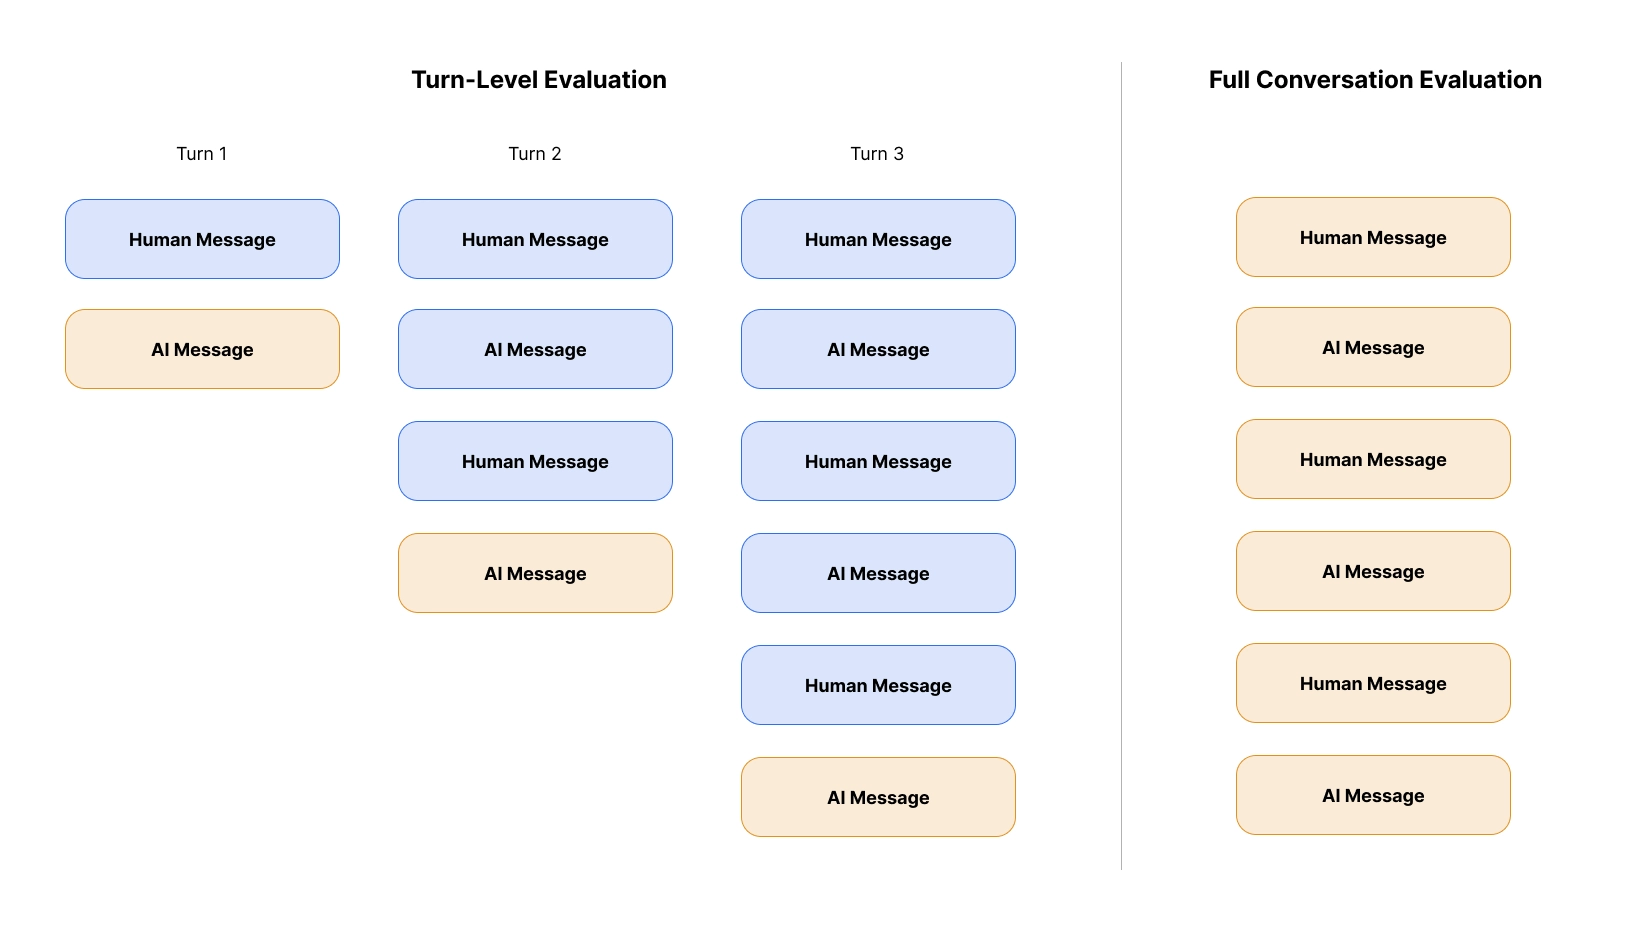


In previous lessons you worked with **reference-based evaluation** — comparing model outputs to predefined expected answers. That works well when there's a clear correct answer, like in classification tasks.

But for our diet planning chatbot, reference-based evaluation has two problems:

- For **online evaluation**, there are no reference outputs — the conversations already happened
- For **conversational AI**, each interaction can unfold in many valid ways, making it impractical to predefine a "correct" response

So here's a question for you: if we can't compare against a reference answer, how might we still evaluate whether the chatbot did a good job?

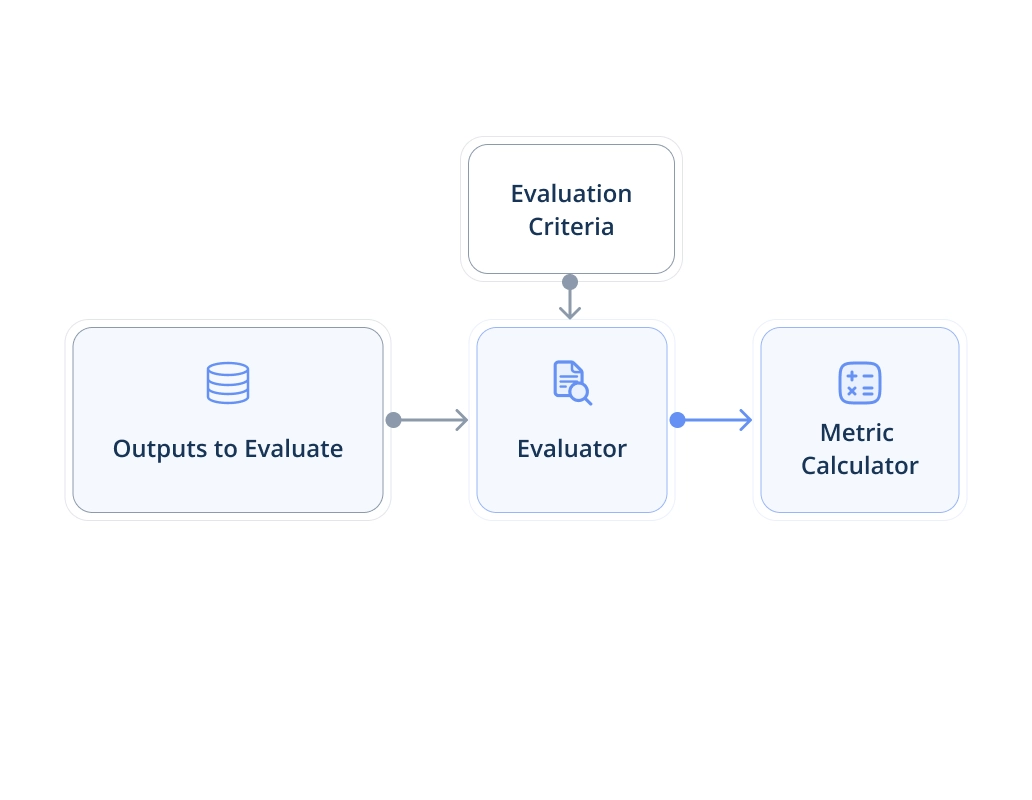


The underlying approach is called criteria-based evaluation — instead of comparing against a reference answer, you assess outputs against predefined quality criteria like coherence, task completion, or efficiency. The LLM judge is then the mechanism that applies those criteria.

As you can see here, the flow is:

- **Outputs to evaluate** → passed to the **Evaluator** (which applies the criteria) → **Metric Calculator** aggregates the scores

This works well for conversational AI because responses can vary widely and there's often no single "correct" answer.

Using llm-as-judge scalability is a key advantage. You can evaluate large volumes without manual intervention.

A few more worth highlighting:

- Consistency: The same criteria are applied standardly across all assessments
- Explainability: The LLM judge provides reasoning for each score, not just a number
- Flexibility: You can easily modify criteria or add new dimensions as your needs evolve
- Integration: Works seamlessly with LangSmith's evaluation infrastructure

Now, to make sure we're fully aligned — how would you explain the difference between reference-based and criteria-based evaluation to a peer who hasn't encountered these concepts before?

`yes but the personalized meal plan is part of the system message to the app. So that defines already quite some criteria... if not it can go all direections`

That's a really insightful point. You're essentially saying the system message constrains the solution space, which makes criteria more natural to derive — and you're right. If the system message says "help users create a personalized meal plan", then task completeness becomes an obvious criterion because it's literally the stated goal.

So in practice, good criteria are often derived directly from the system message — they reflect what the app is supposed to do. The evaluation criteria become a formalization of those expectations.

Where it gets interesting is criteria that go beyond the task itself — like medical soundness (is the advice safe?) or efficiency (did it take too many steps?). Those aren't always spelled out in the system message but matter for real-world quality.

So the system message is a great starting point for criteria, but a thorough evaluation adds dimensions the app can't self-assess.

How would you now explain the difference between reference-based and criteria-based evaluation to a peer

`reference based is ground truth and criteria based gives more room for interpretation?`

That's a solid intuition! A slightly more precise framing:

- Reference-based: compares output to a predefined "correct" answer — works when there's one right answer
- Criteria-based: assesses output against quality dimensions (like coherence or task completion) — works when many valid responses exist

The "room for interpretation" you mentioned is exactly why we need an LLM judge rather than a simple string match — the criteria require judgment, not just comparison.

We're well aligned. Ready to move on to how we'll apply this to our diet planning chatbot?

#### `llm-as-judge` for offline evaluation

For our diet planning chatbot, we'll use full conversation evaluation against criteria — here's the reasoning:

- We care most about whether the assistant successfully helps users create an appropriate diet plan — that can only be assessed at the conversation level, not turn by turn
- Key aspects like information gathering efficiency and plan quality only make sense when you see the full interaction
- And since we're doing online evaluation, developing reference outputs for every possible conversation is simply impractical

Does this approach make sense before we move to defining the specific criteria?

`yes ... so in general ground truth will not work in general for evaluation?`

Not exactly — reference-based evaluation works well in specific cases. The key question is whether there's a well-defined correct answer.

- Works well: Classification tasks, question-answering with factual answers, code that must produce a specific output
- Breaks down: Conversational AI, open-ended generation, tasks where many valid responses exist

For the kinds of LLM applications you're likely building — RAG systems, agents, chatbots — criteria-based evaluation tends to be more appropriate because the output space is too wide for ground truth to be practical at scale.

That said, even in conversational apps, you can sometimes use reference-based evaluation for specific turns where the correct behavior is unambiguous (e.g., "when asked for calorie count, always provide a number").

Ready to define the criteria for our chatbot?

`The final result should be a meal plan to get there the chatbot needs to gather first sufficient input. I say everytime questions about dietary whishes the current eat pattern etc`

Great thinking — you've already identified two natural criteria: whether the final meal plan was produced (task completeness) and how well the chatbot gathered the right information (efficiency). Those map directly to what we define here.

We'll evaluate four criteria for each conversation:

- Task Completeness (0-1): How effectively the assistant helped create a personalized diet plan
- Medical Soundness (0-1): Whether the advice follows safe, evidence-based nutritional guidelines — this goes beyond the task itself, as you noted earlier
- Efficiency (0-1): How efficiently the assistant gathered information and reached a solution without unnecessary back-and-forth
- Coherence (0-1): How well the assistant maintained context throughout — did it remember what the user said earlier?

Each criterion also includes an explanation field so the judge justifies its score, giving you transparency into the reasoning.

Any questions about the criteria before we move to implementation?

`but two wich two are was my previous answer mapped. It sees more the first that combines a lot`

Good question — your answer mapped to two criteria:

- Task Completeness: "the final result should be a meal plan" → did the assistant actually deliver it?
- Efficiency: "needs to gather sufficient input" → did it ask the right questions without unnecessary repetition?

You're right that your answer felt like one combined idea — that's because both are closely linked in practice. Efficiency is really about how well the chatbot navigates toward task completion. Medical Soundness and Coherence are the two additional dimensions we add on top.

Any other questions before we move to implementation?


## Implementation

Here's the plan for implementing the full evaluation:

- Dataset Creation: We already did this — each example is a full conversation from the database
- Evaluator Definition: Define the LLM-as-judge evaluator that scores each conversation against our four criteria
- Experiment Execution: Run the evaluation via LangSmith's evaluate() function and visualize the results

All clear to move into the evaluator implementation?

an **LLM as Judge** is the right choice here, for three reasons:

- We have no reference outputs to compare against
- The criteria involve subjective judgment — conversation flow, task completion quality — that algorithms can't easily capture
- An LLM can reason about complex conversational dynamics in a way a rule-based evaluator can't

As you can see here, the Evaluator block is where the LLM judge sits — it receives the criteria from above and the conversation to evaluate, then passes scores to the metric calculator.

Any questions before we look at the implementation?

In [14]:
import sqlite3
import os
import json
from langsmith import Client, evaluate
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field
from typing import Dict, List
from openai import OpenAI
from dotenv import load_dotenv
from pprint import pprint
from openevals.llm import create_llm_as_judge

load_dotenv()

# Constants
DB_PATH = "conversations.db"


def load_conversations():
    """Load conversations from SQLite DB and format for evaluation"""
    conversations = {}

    # Connect to DB and fetch conversations
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM message_store ORDER BY session_id, id")

    # Process results
    for row in cursor.fetchall():
        session_id = row[1]
        message_data = json.loads(row[2])

        # Skip system messages
        if message_data.get("type") == "system":
            continue

        # Initialize conversation list for this session if needed
        if session_id not in conversations:
            conversations[session_id] = []

        # Get content and role
        content = message_data.get("data", {}).get("content", "")
        role = "user" if message_data.get("type") == "human" else "assistant"

        conversations[session_id].append({"role": role, "content": content})

    # Format for LangSmith
    examples = []
    for messages in conversations.values():
        if len(messages) >= 2:  # Only include conversations with at least one exchange
            examples.append({"inputs": {"conversation": messages}})

    return examples


def create_dataset(client: Client, dataset_name: str, examples: List[Dict]):
    if client.has_dataset(dataset_name=dataset_name):
        print(f"Using existing dataset: {dataset_name}")
    else:
        dataset = client.create_dataset(
            dataset_name, description="Evaluation dataset for conversation quality"
        )
        client.create_examples(
            inputs=[ex["inputs"] for ex in examples], dataset_id=dataset.id
        )
        print(f"Created new dataset: {dataset_name}")


# -----NEW CODE-----#


# Define evaluator model
class ConversationEval(BaseModel):
    task_completeness: float = Field(
        description="How well did the assistant complete the diet planning task? (0-1)"
    )
    task_completeness_explanation: str = Field(
        description="Explanation for the task completeness score"
    )
    medical_soundness: float = Field(
        description="Does the diet advice follow safe, evidence-based nutritional guidelines? (0-1)"
    )
    medical_soundness_explanation: str = Field(
        description="Explanation for the medical soundness score"
    )
    efficiency: float = Field(
        description="How efficiently did the assistant complete the task? (0-1)"
    )
    efficiency_explanation: str = Field(
        description="Explanation for the efficiency score"
    )
    coherence: float = Field(description="How coherent were the responses? (0-1)")
    coherence_explanation: str = Field(
        description="Explanation for the coherence score"
    )


def conversation_quality_evaluator(
    inputs: dict, outputs: dict, reference_outputs: dict = None
):
    """
    Evaluates the quality of a conversation using an LLM as judge.
    Returns scores for coherence, task completeness, and efficiency.
    """
    # Extract conversation from inputs
    conversation = inputs.get("conversation", [])

    # Format conversation for the prompt
    conversation_text = ""
    for msg in conversation:
        conversation_text += f"{msg['role'].upper()}: {msg['content']}\n\n"

    # Define the evaluation prompt
    evaluation_prompt = f"""
        Evaluate this diet planning assistant conversation on four criteria (0-1 scale):
        
        1. **Task Completeness**: How effectively does the assistant help create a personalized diet plan?
           - 1.0: Delivers a complete, personalized meal plan that addresses all user requirements
           - 0.5: Partial plan or missing key personalization elements
           - 0.0: Fails to produce a usable meal plan
        
        2. **Efficiency**: How efficiently does the assistant gather information and reach a solution?
           - 1.0: Gathers necessary information with minimal back-and-forth, no redundant questions
           - 0.5: Some unnecessary questions or repetition, but reaches the goal
           - 0.0: Excessive questions, significant repetition, or very inefficient process
        
        3. **Coherence**: How well does the assistant maintain context throughout the conversation?
           - 1.0: Perfectly remembers and builds upon all previous information
           - 0.5: Generally maintains context with occasional lapses
           - 0.0: Frequently forgets information or contradicts previous statements
        
        4. **Medical Soundness**: Does the diet advice follow safe, evidence-based nutritional guidelines?
           - 1.0: All recommendations are nutritionally sound and safe
           - 0.5: Mostly sound advice with minor questionable suggestions
           - 0.0: Contains potentially harmful or medically unsound recommendations
        
        Provide a score between 0.0 (poor) and 1.0 (excellent) for each criterion.
        For each score, provide a separate explanation justifying your rating.
        
        ---
        CONVERSATION:
        {conversation_text}
        """

    # Create the evaluator
    evaluator = create_llm_as_judge(
        model="gpt-4o",
        prompt=evaluation_prompt,
        continuous=True,
        feedback_key="conversation_eval",
        output_schema=ConversationEval,
    )

    # Run the evaluation
    eval_result = evaluator(inputs={"prompt": evaluation_prompt})

    # Convert the result to the format expected by LangSmith
    return [
        {
            "key": "task_completeness",
            "score": eval_result.task_completeness,
            "comment": eval_result.task_completeness_explanation,
        },
        {
            "key": "medical_soundness",
            "score": eval_result.medical_soundness,
            "comment": eval_result.medical_soundness_explanation,
        },
        {
            "key": "efficiency",
            "score": eval_result.efficiency,
            "comment": eval_result.efficiency_explanation,
        },
        {
            "key": "coherence",
            "score": eval_result.coherence,
            "comment": eval_result.coherence_explanation,
        },
    ]


# for the evaluate api we need a function, since we do not need to run 
# a target model the empty_function is used
def empty_function(x):
    return None


# Initialize LangSmith client
client = Client()

# Load and format conversations
examples = load_conversations()
print(f"Loaded {len(examples)} conversations")

# Create LangSmith dataset
dataset_name = "Diet Assistant Conversations"
create_dataset(client, dataset_name, examples)

# Run evaluation with LLM-as-judge
results = evaluate(
    empty_function,
    data=dataset_name,
    evaluators=[conversation_quality_evaluator],
    experiment_prefix="Diet Assistant Evaluation",
)

Loaded 5 conversations
Using existing dataset: Diet Assistant Conversations
View the evaluation results for experiment: 'Diet Assistant Evaluation-f5ec5b21' at:
https://smith.langchain.com/o/1b1c01bf-b2ed-48d5-9e2a-040bacfc157a/datasets/bc18847d-50f9-4689-b493-30110474f6ae/compare?selectedSessions=9691e492-2083-45f6-98ea-5d29d23aaf0a




0it [00:00, ?it/s]

In [13]:
results_df = results.to_pandas()
results_df

,inputs.conversation,outputs.output,error,feedback.task_completeness,feedback.medical_soundness,feedback.efficiency,feedback.coherence,execution_time,example_id,id
0,"[{'role': 'user', 'content': 'Is there chocola...",None,None,0.0,0.5,0.0,0.5,0.003578,4156f28a-299c-4294-8ee6-e8a4788b0b4f,019e564f-6bd7-7813-8bae-6f7ceca38f24
1,"[{'role': 'user', 'content': 'Is there chocola...",None,None,0.5,1.0,0.5,1.0,0.001347,42c6237e-a451-4738-93ad-b2a628713b03,019e564f-7d4d-73b0-9379-80eb24a1016c
2,"[{'role': 'user', 'content': 'how are you'}, {...",None,None,0.8,1.0,0.7,0.8,0.000496,62254217-fefd-4307-bdc0-6876e7307254,019e564f-89fb-7fc3-8418-7da4120c207f
3,"[{'role': 'user', 'content': 'Is there chocola...",None,None,0.5,1.0,0.5,1.0,0.001159,7c830c0b-b18a-4eaa-bea9-a565d874f6f2,019e564f-9584-7ad3-b3df-f09e49590cee
4,"[{'role': 'user', 'content': 'Is there chocola...",None,None,1.0,1.0,0.5,1.0,0.000525,fb7555b1-d28b-4eaf-997f-aacb8d458f0d,019e564f-a0b5-7f82-9e30-42d832457ff2


In [25]:
eval_summary_df = (
    results_df.agg(
        {
            "feedback.task_completeness": "mean",
            "feedback.medical_soundness": "mean",
            "feedback.efficiency": "mean",
            "feedback.coherence": "mean",
        }
    )
    .reset_index()
    .rename(columns={"index": "metric", 0: "score"})
)

In [26]:
eval_summary_df

,metric,score
0,feedback.task_completeness,0.56
1,feedback.medical_soundness,0.90
2,feedback.efficiency,0.44
3,feedback.coherence,0.86


In [27]:
print(eval_summary_df.to_markdown(index=False))

| metric                     |   score |
|:---------------------------|--------:|
| feedback.task_completeness |    0.56 |
| feedback.medical_soundness |    0.9  |
| feedback.efficiency        |    0.44 |
| feedback.coherence         |    0.86 |


Glad you're enjoying it! And you've put your finger on the real challenge — getting LLM-as-judge to work reliably is genuinely hard. The scoring anchors we used here (1.0, 0.5, 0.0 with explicit descriptions) are one of the most effective techniques to reduce variance, but there's always some non-determinism.

In practice, teams also run evaluations multiple times and average the scores, use stronger models (GPT-4o is a good choice), and calibrate against human judgments to validate that the judge's scores actually correlate with what humans care about.

It's an active area — there's no perfect solution yet, which is partly why human evaluation still has a role. Ready to wrap up with the summary?

## Summary

#### Chatbot Evaluation Overview

- Offline evaluation tests during development with controlled examples before release, while online evaluation analyzes actual production data to identify edge cases and improvement opportunities

- Evaluation can be done at turn-level (individual AI responses) or full conversation level (complete interactions from start to finish)

- While reference-based evaluation compares outputs to predefined "correct" answers, criteria-based evaluation assesses outputs against quality criteria like coherence and task completion, making it more suitable for conversational AI where many valid responses exist

#### Criteria-Based Evaluation Implementation

- The LLM-as-judge approach uses a Pydantic model to structure evaluations across the selected criteria. For instance, coherence (contextual consistency), task completeness (achieving user goals), and efficiency (reaching solutions without unnecessary steps

```python
class ConversationEval(BaseModel):
    coherence: float = Field(description="How coherent were the responses? (0-1)")
    coherence_explanation: str = Field(
        description="Explanation for the coherence score"
    )
    task_completeness: float = Field(
        description="How well did the assistant complete the task? (0-1)"
    )
    task_completeness_explanation: str = Field(
        description="Explanation for the task completeness score"
    )
    efficiency: float = Field(
        description="How efficiently did the assistant gather information? (0-1)"
    )
    efficiency_explanation: str = Field(
        description="Explanation for the efficiency score"
    )


def conversation_quality_evaluator(
    inputs: dict, outputs: dict, reference_outputs: dict = None
):
    """Evaluates the quality of a conversation using an LLM as judge."""
    conversation = inputs.get("conversation", [])

    # Format conversation for the prompt
    conversation_text = ""
    for msg in conversation:
        conversation_text += f"{msg['role'].upper()}: {msg['content']}\n\n"

    # Create the evaluator
    evaluator = create_llm_as_judge(
        judge=judge_llm,
        prompt=evaluation_prompt,
        continuous=True,
        feedback_key="conversation_eval",
        output_schema=ConversationEval,
    )

    # Run evaluation and return formatted results
    eval_result = evaluator(inputs={"prompt": evaluation_prompt})
    return [
        {
            "key": "coherence",
            "score": eval_result.coherence,
            "comment": eval_result.coherence_explanation,
        },
        {
            "key": "task_completeness",
            "score": eval_result.task_completeness,
            "comment": eval_result.task_completeness_explanation,
        },
        {
            "key": "efficiency",
            "score": eval_result.efficiency,
            "comment": eval_result.efficiency_explanation,
        },
    ]
```

- Implementation follows three steps:
    - Creating a dataset from chat history stored in SQLite
    - Defining evaluators that format conversations for LLM judgment
    - Executing experiments through LangSmith's evaluate() function
- This approach offers scalability for large volumes, consistency across assessments, explainability through score justifications, and flexibility to modify criteria as needed